In [1]:
# Cell 1 — environment check and model version
# If you're on a fresh environment, install the client first (same as the sample notebook)
# !pip install --upgrade pip
# !pip install "ase==3.26.0" "pfp-api-client>=1.23.0"
# !pip install tqdm
# !pip install 'matlantis-features>=0.8.1'
# !pip install pacmap "pfcc-extras>=0.12.0" "pfp-api-client>=1.23.1"
# !pip install -U pfp-api-client matlantis-features
# !pip install -U nglview ipywidgets
import matlantis_features
import pfp_api_client
from pfp_api_client.pfp.estimator import Estimator

estimator = Estimator()
print(f"matlantis_features: {matlantis_features.__version__}")
print(f"pfp_api_client: {pfp_api_client.__version__}")
print(f"current pfp model version: {estimator.model_version}")

matlantis_features: 1.0.3
pfp_api_client: 2.2.0
current pfp model version: v8.0.0


In [ ]:
# Cell 2 — imports and basic setup
import logging
import pathlib
import numpy as np
import plotly.graph_objects as go
from plotly.offline import iplot
from IPython.display import clear_output

from ase import Atoms
from ase.io import write
from ase.io.trajectory import Trajectory

from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

from ase import units
from ase.build import bulk

from matlantis_features.atoms import MatlantisAtoms
from matlantis_features.features.md import ASEMDSystem, MDFeature, NPTBerendsenIntegrator
from matlantis_features.features.md.post_features import PostMDSpecificHeatFeature
from matlantis_features.utils.calculators import pfp_estimator_fn
 
from ase.optimize import FIRE
from pacmap import LocalMAP
import plotly.express as px
from rdkit import Chem
from tqdm import tqdm

from pfcc_extras.structure.ase_rdkit_converter import smiles_to_atoms
from pfcc_extras.visualize import view_ngl
from pfp_api_client import ASECalculator, Estimator, EstimatorCalcMode

try:
    dir_path = pathlib.Path(__file__).parent
except:
    dir_path = pathlib.Path("").resolve()

logger = logging.getLogger("matlantis_features")
logger.setLevel(logging.INFO)

In [5]:
# Cell 3 — structure construction helpers
def build_cubic_perovskite_ab_o3_tagged(a=3.90, A="La", B="Co"):
    """
    Build a cubic perovskite ABO3 primitive cell (Pm-3m).
    Positions in fractional coordinates:
      A: (0,0,0)
      B: (1/2,1/2,1/2)
      O: (1/2,1/2,0), (1/2,0,1/2), (0,1/2,1/2)
    """
    symbols = [A, B, "O", "O", "O"]
    scaled_positions = [
        (0.0, 0.0, 0.0),
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.0),
        (0.5, 0.0, 0.5),
        (0.0, 0.5, 0.5),
    ]
    cell = np.eye(3) * a
    atoms = Atoms(symbols=symbols, scaled_positions=scaled_positions, cell=cell, pbc=True)

    # Tag sublattices: A=1, B=2, O=3
    atoms.set_tags([1, 2, 3, 3, 3])
    return atoms

def indices_by_tag(atoms, tag_value):
    return [i for i, t in enumerate(atoms.get_tags()) if t == tag_value]

def assign_species_by_counts(atoms, site_indices, species, fractions, seed=0):
    """
    Assign species to site_indices with exact integer counts (sum == len(site_indices)).
    Fractions are converted to counts by rounding, then corrected to match the total.
    """
    rng = np.random.default_rng(seed)
    n = len(site_indices)

    fractions = np.array(fractions, dtype=float)
    fractions = fractions / fractions.sum()

    # Initial counts via rounding
    counts = np.rint(fractions * n).astype(int)

    # Fix rounding drift to ensure sum(counts) == n
    diff = n - counts.sum()
    if diff != 0:
        # distribute the difference based on largest fractional remainders
        raw = fractions * n
        rema = raw - np.floor(raw)
        order = np.argsort(-rema)  # descending
        for k in range(abs(diff)):
            j = order[k % len(order)]
            counts[j] += 1 if diff > 0 else -1

    assert counts.sum() == n
    assert np.all(counts >= 0)

    # Build assignment list and shuffle
    assignment = []
    for sp, c in zip(species, counts):
        assignment += [sp] * int(c)
    assignment = np.array(assignment, dtype=object)
    rng.shuffle(assignment)

    for idx, sp in zip(site_indices, assignment):
        atoms[idx].symbol = sp

    return counts


In [7]:
# Cell 4 — dataset configuration and job preview

# Material configurations for the A site.
configurations = {
    "LE_1": (["La", "Sr"], [0.6, 0.4]),
    "LE_2": (["La", "Sr", "Ca"], [0.6, 0.2, 0.2]),
    "LE_3": (["La", "Ca"], [0.6, 0.4]),
    "HE_2": (["La", "Sr", "Ca", "Nd", "Y"], [0.2, 0.2, 0.2, 0.2, 0.2]),
    "HE_3": (["La", "Sr", "Ca", "Nd", "Sm"], [0.2, 0.2, 0.2, 0.2, 0.2]),
    "HE_4": (["La", "Sr", "Ca", "Gd", "Sm"], [0.2, 0.2, 0.2, 0.2, 0.2]),
    "HE_5": (["La", "Sr", "Ba", "Gd", "Nd"], [0.2, 0.2, 0.2, 0.2, 0.2]),
    "HE_6": (["La", "Sr", "Ba", "Ca", "Nd"], [0.4, 0.2, 0.1, 0.1, 0.2]),
    "HE_7": (["La", "Ba", "Ca", "Nd", "Y"], [0.2, 0.1, 0.3, 0.2, 0.2]),
    "HE_10": (["La", "Sr", "Gd", "Sm", "Y"], [0.2, 0.2, 0.2, 0.2, 0.2]),
}

temperatures_K = list(range(300, 1101, 200)) 
o_vac_list = [0,3,6,9,12]
n_reps = 3

out_dir = "npt_final"
os.makedirs(out_dir, exist_ok=True)

def run_tag(config_name, n_vac, rep, T):
    return f"{config_name}__Ov{n_vac:02d}__r{rep:02d}__T{int(T):04d}K"

jobs = []

for config_name in configurations.keys():
    for n_vac in o_vac_list:
        for rep in range(n_reps):
            for T in temperatures_K:
                tag = run_tag(config_name, n_vac, rep, T)
                traj_path = os.path.join(out_dir, f"{tag}.traj")
                jobs.append(traj_path)

print("Total jobs =", len(jobs))
print("\nFirst 10 jobs:")
for p in jobs[:10]:
    print(p)


Total jobs = 75

First 10 jobs:
npt_grid_ov/LE_1__Ov00__r00__T0300K.traj
npt_grid_ov/LE_1__Ov00__r00__T0500K.traj
npt_grid_ov/LE_1__Ov00__r00__T0700K.traj
npt_grid_ov/LE_1__Ov00__r00__T0900K.traj
npt_grid_ov/LE_1__Ov00__r00__T1100K.traj
npt_grid_ov/LE_1__Ov00__r01__T0300K.traj
npt_grid_ov/LE_1__Ov00__r01__T0500K.traj
npt_grid_ov/LE_1__Ov00__r01__T0700K.traj
npt_grid_ov/LE_1__Ov00__r01__T0900K.traj
npt_grid_ov/LE_1__Ov00__r01__T1100K.traj


In [8]:
# Cell 5 — oxygen vacancy and structure generation helpers
import numpy as np
from collections import Counter
from dataclasses import dataclass

@dataclass(frozen=True)
class OVSpec:
    n_vac: int
    seed: int

def apply_oxygen_vacancies(atoms, o_idx, ov: OVSpec):
    if ov.n_vac <= 0:
        return []
    if ov.n_vac > len(o_idx):
        raise ValueError(f"n_vac={ov.n_vac} > n_O_sites={len(o_idx)}")

    rng = np.random.default_rng(ov.seed)
    remove = rng.choice(o_idx, size=ov.n_vac, replace=False).tolist()

    for idx in sorted(remove, reverse=True):
        del atoms[idx]
    return remove

def build_structure(config_name, n_vac, rep,
                    base_atoms, a_idx, b_idx, o_idx,
                    seed_base=1000):
    a_species, a_frac = configurations[config_name]

    seed_A = seed_base + 10*rep + 1
    seed_B = seed_base + 10*rep + 2
    seed_O = seed_base + 10*rep + 3

    atoms = base_atoms.copy()

    assign_species_by_counts(atoms, a_idx, species=a_species, fractions=a_frac, seed=seed_A)
    assign_species_by_counts(atoms, b_idx, species=["Co", "Fe"], fractions=[0.2, 0.8], seed=seed_B)

    removed = apply_oxygen_vacancies(atoms, o_idx, OVSpec(n_vac=n_vac, seed=seed_O))

    return atoms, removed

def quick_check(atoms, removed, config_name, n_vac, rep):
    counts = Counter(atoms.get_chemical_symbols())
    print(f"\n=== check: {config_name}, Ov={n_vac}, rep={rep} ===")
    print("Total atoms:", len(atoms))
    print("Removed O indices (before deletion):", removed)
    print("Element counts:", dict(counts))
    print("O count:", counts.get("O", 0))


In [9]:
# Cell 6 — build base supercell and assign compositions once
from pfp_api_client.pfp.calculators.ase_calculator import ASECalculator
from pfp_api_client.pfp.estimator import Estimator

a0 = 3.90
prim = build_cubic_perovskite_ab_o3_tagged(a=a0, A="La", B="Co")
atom_copy = prim.repeat((5, 5, 5))  # 375 atoms

a_idx = indices_by_tag(atom_copy, 1)  # A sites, should be 125
b_idx = indices_by_tag(atom_copy, 2)  # B sites, should be 125
o_idx = indices_by_tag(atom_copy, 3)  # O sites, should be 375 

print(len(a_idx), len(b_idx), len(o_idx))

a_counts = []
b_counts = []
atoms_list = []
name_list=[]
for name, (a_species, a_frac) in configurations.items():
    atoms_i = atom_copy.copy()
    # A-site
    a_count_i = assign_species_by_counts(atoms_i, a_idx, species=a_species, fractions=a_frac, seed=42)
    # B-site
    b_count_i = assign_species_by_counts(atoms_i, b_idx, species=["Co", "Fe"], fractions=[0.2, 0.8], seed=43)

    atoms_i.calc = ASECalculator(Estimator())

    a_counts.append(a_count_i)
    b_counts.append(b_count_i)
    atoms_list.append(atoms_i)
    name_list.append(name)
    print(name)
    print("A counts (", a_species, "): ", a_count_i, "; sum = ", a_count_i.sum())
    print("B counts (", ["Co", "Fe"], "): ", b_count_i, "; sum = ", b_count_i.sum())


125 125 375
LE_1
A counts ( ['La', 'Sr'] ):  [75 50] ; sum =  125
B counts ( ['Co', 'Fe'] ):  [ 25 100] ; sum =  125


In [10]:
# Cell 6 — build base supercell and assign compositions once

from matlantis_features.utils.atoms_util import convert_atoms_to_upper

mat_atoms_list = []

for name, atoms_i in zip(name_list, atoms_list):
    atoms_m = MatlantisAtoms.from_ase_atoms(convert_atoms_to_upper(atoms_i))
    mat_atoms_list.append(atoms_m)

    # print(f"\n==== {name} ====")
    # print("Cell lengths (A):", atoms_m.ase_atoms.cell.lengths())
    # print("Cell (A):\n", atoms_m.ase_atoms.cell.array)
    # print("Min length (A):", min(atoms_m.ase_atoms.cell.lengths()))



In [11]:
# Cell 8 — MD runner

def run_md(atoms, temperature, n_run, traj_freq=1,
           logger_interval=100, pressure=0.0,
           compressibility=67.2, # Water
           timestep=1.0, taut=None, taup=None,
           traj_file=None):
    if traj_file is None:
        traj_file = f'output/md_npt_thermal_expansion_{str(temperature).zfill(4)}K.traj'

    if taut is None: taut = 5000*timestep / 1000  # fs
    if taup is None: taup = 50000*timestep / 1000 # fs
    npt = NPTBerendsenIntegrator(
        timestep=timestep, taut=taut, taup=taup,
        temperature=temperature, pressure=pressure, 
        compressibility=compressibility
    )
    mdsys = ASEMDSystem(atoms)
    mdsys.init_temperature(temperature)

    md = MDFeature(
        integrator=npt,
        traj_file_name=traj_file, traj_freq=traj_freq,
        n_run=n_run, show_progress_bar=True,
        show_logger=True,
        logger_interval=logger_interval,
        estimator_fn=estimator_fn,
    )
    md_res = md(mdsys)
    return md, md_res

In [13]:
# Cell 8 — MD runner
from ase.io import Trajectory, write

# Simulation parameters.
temperatures_K = list(range(300, 1101, 200))
o_vac_list = [0,3,6,9,12]
n_reps = 3

bulk_mod_Pa = 100e9
pressure_Pa = 0.0

timestep_fs = 1.0
taut_fs = 10.0
taup_fs = 100.0
equil_steps = 2000
write_stride = 10

base_out_dir = "npt_final"

traj_root = os.path.join(base_out_dir, "traj")
xyz_root  = os.path.join(base_out_dir, "xyz")

os.makedirs(traj_root, exist_ok=True)
os.makedirs(xyz_root, exist_ok=True)

def run_tag(config_name, n_vac, rep, T):
    return f"{config_name}__Ov{n_vac:02d}__r{rep:02d}__T{int(T):04d}K"

skip_if_exists = True

for config_name in configurations.keys():

    material_traj_dir = os.path.join(traj_root, config_name)
    material_xyz_dir  = os.path.join(xyz_root,  config_name)

    os.makedirs(material_traj_dir, exist_ok=True)
    os.makedirs(material_xyz_dir,  exist_ok=True)

    for n_vac in o_vac_list:
        for rep in range(n_reps):

            # Build one disordered structure for this composition/vacancy/replicate.
            atoms0, removed = build_structure(
                config_name=config_name,
                n_vac=n_vac,
                rep=rep,
                base_atoms=atom_copy,
                a_idx=a_idx, b_idx=b_idx, o_idx=o_idx
            )
            atoms0.calc = ASECalculator(Estimator())

            print(f"\nBuilt: {config_name}, Ov={n_vac}, rep={rep}, "
                  f"N={len(atoms0)}, removed_O={len(removed)}")

            for T in temperatures_K:

                tag = run_tag(config_name, n_vac, rep, T)

                traj_path = os.path.join(material_traj_dir, f"{tag}.traj")
                xyz_path  = os.path.join(material_xyz_dir,  f"{tag}.extxyz")

                if skip_if_exists and os.path.exists(traj_path):
                    print("skip existing:", tag)
                    continue

                atoms_T = atoms0.copy()
                atoms_T.calc = atoms0.calc

                # Run NPT MD.
                run_md(
                    atoms_T, T, equil_steps,
                    taut=taut_fs, taup=taup_fs,
                    traj_file=traj_path,
                    pressure=pressure_Pa*units.Pascal,
                    compressibility=1/(bulk_mod_Pa*units.Pascal),
                    timestep=timestep_fs
                )

                # Export trajectory frames to extxyz with a fixed stride.
                traj = Trajectory(traj_path)
                write(xyz_path, traj[::write_stride])

                print("done:", tag, "frames=", len(traj))



Built: LE_1, Ov=0, rep=0, N=625, removed_O=0
skip existing: LE_1__Ov00__r00__T0300K
skip existing: LE_1__Ov00__r00__T0500K
skip existing: LE_1__Ov00__r00__T0700K
skip existing: LE_1__Ov00__r00__T0900K
skip existing: LE_1__Ov00__r00__T1100K

Built: LE_1, Ov=4, rep=0, N=621, removed_O=4
skip existing: LE_1__Ov04__r00__T0300K
skip existing: LE_1__Ov04__r00__T0500K
skip existing: LE_1__Ov04__r00__T0700K
skip existing: LE_1__Ov04__r00__T0900K
skip existing: LE_1__Ov04__r00__T1100K

Built: LE_1, Ov=8, rep=0, N=617, removed_O=8


  0%|          | 0/2000 [00:00<?, ?it/s]

The MD trajectory will be saved at /home/jovyan/ML_HEPO/diff_com_T_OV/npt_grid_ov_0.1_3rep/traj/LE_1/LE_1__Ov08__r00__T0300K.traj.
Note: The max disk size of /home/jovyan is about 98G.
steps:     0  energy：-5.66 eV/atom  total energy: -5.62 eV/atom  temperature: 301.10 K  volume:  7415 Ang^3  density: 6.210 g/cm^3
steps:   100  energy：-5.65 eV/atom  total energy: -5.61 eV/atom  temperature: 312.48 K  volume:  7345 Ang^3  density: 6.269 g/cm^3
steps:   200  energy：-5.66 eV/atom  total energy: -5.62 eV/atom  temperature: 299.57 K  volume:  7340 Ang^3  density: 6.273 g/cm^3
steps:   300  energy：-5.65 eV/atom  total energy: -5.62 eV/atom  temperature: 291.76 K  volume:  7351 Ang^3  density: 6.264 g/cm^3
steps:   400  energy：-5.65 eV/atom  total energy: -5.62 eV/atom  temperature: 296.31 K  volume:  7340 Ang^3  density: 6.273 g/cm^3
steps:   500  energy：-5.65 eV/atom  total energy: -5.62 eV/atom  temperature: 299.52 K  volume:  7352 Ang^3  density: 6.263 g/cm^3
steps:   600  energy：-5.66 eV

done: LE_1__Ov08__r00__T0300K frames= 2000


  0%|          | 0/2000 [00:00<?, ?it/s]

...

The MD trajectory will be saved at /home/jovyan/ML_HEPO/diff_com_T_OV/npt_grid_ov_0.1_3rep/traj/LE_1/LE_1__Ov12__r00__T0900K.traj.
Note: The max disk size of /home/jovyan is about 98G.
steps:     0  energy：-5.66 eV/atom  total energy: -5.54 eV/atom  temperature: 880.19 K  volume:  7415 Ang^3  density: 6.195 g/cm^3
steps:   100  energy：-5.56 eV/atom  total energy: -5.44 eV/atom  temperature: 911.31 K  volume:  7549 Ang^3  density: 6.085 g/cm^3
steps:   200  energy：-5.58 eV/atom  total energy: -5.46 eV/atom  temperature: 887.71 K  volume:  7630 Ang^3  density: 6.020 g/cm^3
steps:   300  energy：-5.58 eV/atom  total energy: -5.46 eV/atom  temperature: 925.07 K  volume:  7640 Ang^3  density: 6.013 g/cm^3
steps:   400  energy：-5.57 eV/atom  total energy: -5.46 eV/atom  temperature: 893.15 K  volume:  7648 Ang^3  density: 6.007 g/cm^3
steps:   500  energy：-5.57 eV/atom  total energy: -5.45 eV/atom  temperature: 894.18 K  volume:  7653 Ang^3  density: 6.002 g/cm^3
steps:   600  energy：-5.57 eV

done: LE_1__Ov12__r00__T0900K frames= 2000


  0%|          | 0/2000 [00:00<?, ?it/s]

The MD trajectory will be saved at /home/jovyan/ML_HEPO/diff_com_T_OV/npt_grid_ov_0.1_3rep/traj/LE_1/LE_1__Ov12__r00__T1100K.traj.
Note: The max disk size of /home/jovyan is about 98G.
steps:     0  energy：-5.66 eV/atom  total energy: -5.52 eV/atom  temperature: 1095.17 K  volume:  7415 Ang^3  density: 6.195 g/cm^3
steps:   100  energy：-5.53 eV/atom  total energy: -5.38 eV/atom  temperature: 1092.04 K  volume:  7599 Ang^3  density: 6.045 g/cm^3
steps:   200  energy：-5.55 eV/atom  total energy: -5.41 eV/atom  temperature: 1135.93 K  volume:  7729 Ang^3  density: 5.944 g/cm^3
steps:   300  energy：-5.54 eV/atom  total energy: -5.40 eV/atom  temperature: 1095.35 K  volume:  7752 Ang^3  density: 5.926 g/cm^3
steps:   400  energy：-5.54 eV/atom  total energy: -5.40 eV/atom  temperature: 1100.63 K  volume:  7770 Ang^3  density: 5.912 g/cm^3
steps:   500  energy：-5.54 eV/atom  total energy: -5.40 eV/atom  temperature: 1086.73 K  volume:  7768 Ang^3  density: 5.914 g/cm^3
steps:   600  energy：-5

done: LE_1__Ov12__r00__T1100K frames= 2000


In [ ]:
# Cell 10 — inspect one trajectory
from ase.io import Trajectory
from ase.visualize import view
from pfcc_extras.visualize import view_ngl

from ase.optimize import FIRE
from ase.io import Trajectory
from pacmap import LocalMAP
import plotly.express as px
from rdkit import Chem
from tqdm import tqdm

from pfcc_extras.structure.ase_rdkit_converter import smiles_to_atoms
from pfcc_extras.visualize import view_ngl
from pfp_api_client import ASECalculator, Estimator, EstimatorCalcMode

traj = Trajectory("npt_grid_ov_0.1_3rep/traj/LE_1/LE_1__Ov12__r00__T1100K.traj")
view_ngl(traj, representations=["ball+stick"])

279.076485988833 K -6.811654185635772 GPa


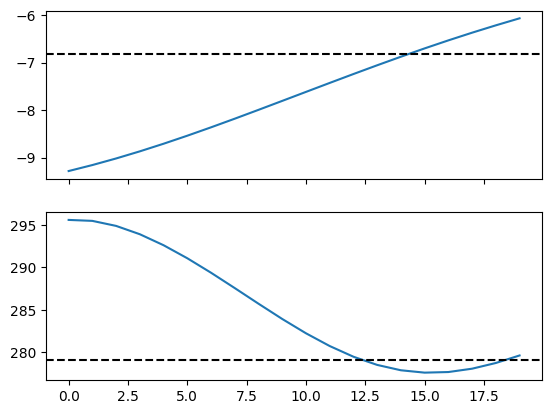

In [29]:
# Cell 11 — pressure and temperature evolution

volumes = []
temps = []
stress = []
for f, atoms_obj in enumerate(traj):
    vol = atoms_obj.get_volume()
    T = atoms_obj.get_temperature()
    s = atoms_obj.get_stress() #include_ideal_gas=True)
    volumes.append(vol)
    temps.append(T)
    stress.append(s)
# p_eq = np.mean(press[(len(press)//2):])/units.GPa
s_array = np.array(stress)/units.GPa
p_array = -np.mean(s_array[:, :3], axis=1)
p_eq = np.mean(p_array[(len(temps)//2):])
T_eq = np.mean(temps[(len(temps)//2):])

print(T_eq, 'K', p_eq, 'GPa')

fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].plot(p_array)
axs[0].axhline(p_eq, linestyle='--', color='k')
axs[1].plot(temps)
axs[1].axhline(T_eq, linestyle='--', color='k')
plt.show()